Exercise 1: Implement kmeans clustering

Load Iris dataset using sklearn.
Apply K-Means clustering with a fixed number of clusters (k=3).
Assign cluster labels to each data point.
Use the Elbow Method to determine the optimal number of clusters.
Plot inertia vs number of clusters to identify the elbow point.
Compare clustering results with and without the Elbow Method.
Implement K-Means clustering using the pyclustering library.
Analyze clusters formed and compare with sklearn results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [2]:
iris = load_iris()
X = iris.data   # features
y = iris.target # actual labels (for comparison only)

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_

print("Cluster Labels:\n", labels)

Cluster Labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


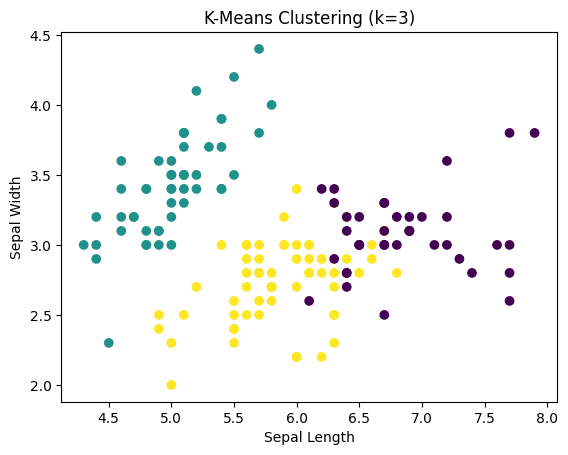

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering (k=3)")
plt.show()

In [5]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

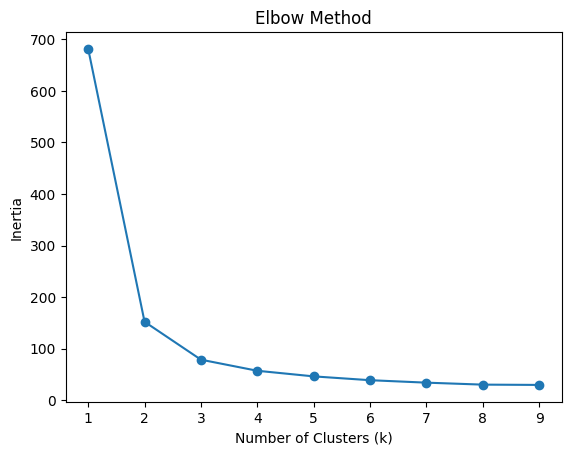

In [6]:
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pyclustering.cluster.kmedoids import kmedoids
import random

In [10]:
iris = load_iris()
X = iris.data

In [11]:
initial_medoids = random.sample(range(len(X)), 3)
print("Initial Medoids Index:", initial_medoids)

Initial Medoids Index: [49, 145, 133]


In [12]:
kmedoids_instance = kmedoids(X, initial_medoids)

kmedoids_instance.process()

clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

print("Final Medoids Index:", medoids)
print("Clusters:", clusters)

Final Medoids Index: [7, 112, 78]
Clusters: [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], [52, 77, 100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 115, 116, 117, 118, 120, 122, 124, 125, 128, 129, 130, 131, 132, 134, 135, 136, 137, 139, 140, 141, 143, 144, 145, 147, 148], [50, 51, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 106, 113, 114, 119, 121, 123, 126, 127, 133, 138, 142, 146, 149]]


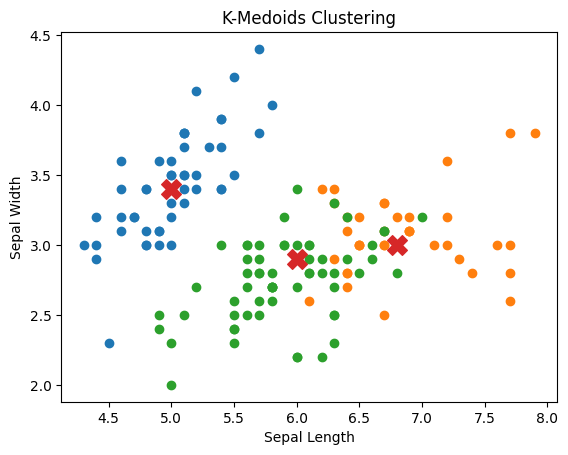

In [13]:
for cluster in clusters:
    plt.scatter(X[cluster, 0], X[cluster, 1])

# Highlight medoids
plt.scatter(X[medoids, 0], X[medoids, 1], marker='X', s=200)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Medoids Clustering")
plt.show()

In [1]:
pip install pyclustering scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from sklearn import datasets
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
iris = datasets.load_iris()
data = iris.data

In [4]:
# choose 3 random medoids (since iris has 3 classes)
initial_medoids = np.random.choice(len(data), 3, replace=False)
print("Initial Medoids Index:", initial_medoids)

Initial Medoids Index: [ 45  72 143]


In [5]:
kmedoids_instance = kmedoids(data, initial_medoids.tolist())

# Run clustering
kmedoids_instance.process()

# Get clusters and medoids
clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

In [6]:
print("\nFinal Medoids Index:", medoids)

for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1} size:", len(cluster))


Final Medoids Index: [7, 78, 143]
Cluster 1 size: 50
Cluster 2 size: 65
Cluster 3 size: 35


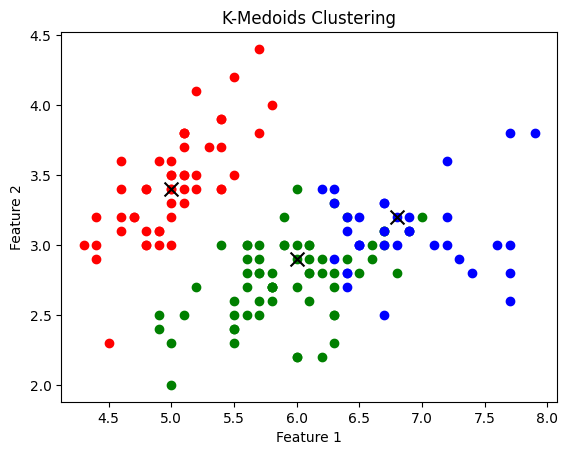

In [7]:
colors = ['r', 'g', 'b']

for i, cluster in enumerate(clusters):
    for index in cluster:
        plt.scatter(data[index][0], data[index][1], c=colors[i])

# plot medoids
for medoid in medoids:
    plt.scatter(data[medoid][0], data[medoid][1], c='black', marker='x', s=100)

plt.title("K-Medoids Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

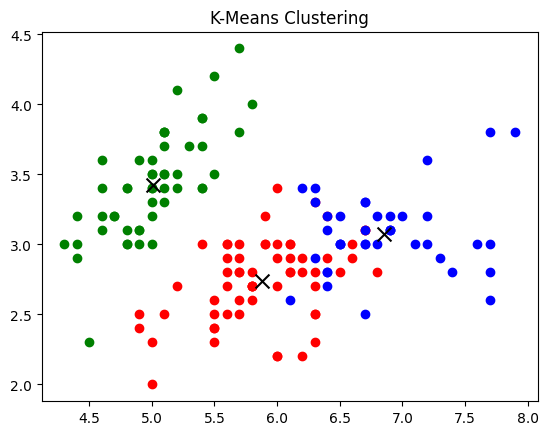

In [8]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(data)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot K-Means
for i in range(len(data)):
    plt.scatter(data[i][0], data[i][1], c=colors[labels[i]])

# plot centroids
for center in centers:
    plt.scatter(center[0], center[1], c='black', marker='x', s=100)

plt.title("K-Means Clustering")
plt.show()